In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_excel("Historical_Sales_Data.xlsx")

df.head()

,Month,Marketing_Spend,Website_Visitors,Sales
0,Jan,28,3653,1573
1,Feb,79,9425,4763
2,Mar,38,4395,2205
3,Apr,67,8035,4035
4,May,55,6784,3320


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Month             12 non-null     object
 1   Marketing_Spend   12 non-null     int64 
 2   Website_Visitors  12 non-null     int64 
 3   Sales             12 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 516.0+ bytes


In [3]:
df.isnull().sum()

,0
Month,0
Marketing_Spend,0
Website_Visitors,0
Sales,0


In [4]:
# Features (Input)
X = df[['Marketing_Spend', 'Website_Visitors']]

# Target (Output)
y = df['Sales']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", len(X_train))
print("Testing Data:", len(X_test))

Training Data: 9
Testing Data: 3


In [6]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [7]:
predictions = model.predict(X_test)

print("Predicted Sales:")
print(predictions)

Predicted Sales:
[1776.81577986 4384.86851601 1820.71446357]


In [8]:
comparison = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': predictions
})

comparison

,Actual Sales,Predicted Sales
0,1675,1776.815780
1,4379,4384.868516
2,1573,1820.714464


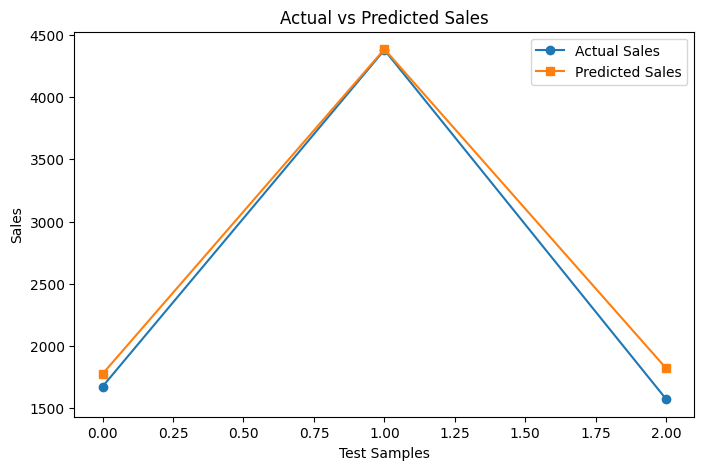

In [9]:
plt.figure(figsize=(8,5))

plt.plot(y_test.values, marker='o', label='Actual Sales')
plt.plot(predictions, marker='s', label='Predicted Sales')

plt.title("Actual vs Predicted Sales")
plt.xlabel("Test Samples")
plt.ylabel("Sales")
plt.legend()

plt.show()

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 118.46625314296436
Mean Squared Error (MSE): 23921.115989389247
R² Score: 0.9858321322946174


In [11]:
comparison.to_excel("Sales_Prediction_Output.xlsx", index=False)

print("Prediction results saved successfully!")

Prediction results saved successfully!


In [12]:
df.to_excel("Historical_Data_Final.xlsx", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!
